In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers,models
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#Load CIFAR-10 dataset

In [5]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

In [6]:
print("Training data shape: ",x_train.shape)
print("Testing data shape",x_test.shape)

Training data shape:  (50000, 32, 32, 3)
Testing data shape (10000, 32, 32, 3)


In [7]:
#Class names
class_names=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

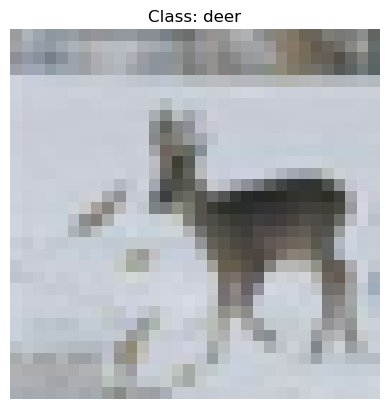

In [29]:
#Display one image
plt.imshow(x_train[20])
plt.title("Class: "+class_names[y_train[20][0]])
plt.axis('off')
plt.show()

In [61]:
#normalize pixel values
x_train=x_train/255.0
x_test=x_test/255.0

In [63]:
# Create CNN model
model=models.Sequential()
#Convolution Layer 1
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))

In [65]:
#Pooling Layers1
model.add(layers.MaxPooling2D(2,2))

In [69]:
#Convolution Layer 2
model.add(layers.Conv2D(64,(3,3),activation='relu'))

In [73]:
#Pooling Layers2
model.add(layers.MaxPooling2D(2,2))

In [77]:
#Convolution Layer 3
model.add(layers.Conv2D(64,(3,3),activation='relu'))

In [79]:
#Flatten
model.add(layers.Flatten())

In [81]:
#Fully Connected Layer
model.add(layers.Dense(64,activation='relu'))
#Output Layers
model.add(layers.Dense(10,activation='softmax'))
#Display model atchitecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7951 - loss: 0.5819 - val_accuracy: 0.7046 - val_loss: 0.9200
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8058 - loss: 0.5501 - val_accuracy: 0.6971 - val_loss: 0.9541
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8166 - loss: 0.5206 - val_accuracy: 0.7087 - val_loss: 0.9258
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8244 - loss: 0.4942 - val_accuracy: 0.7125 - val_loss: 0.9455
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8342 - loss: 0.4653 - val_accuracy: 0.7085 - val_loss: 0.9479
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8429 - loss: 0.4372 - val_accuracy: 0.7018 - val_loss: 1.0217
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8525 - loss: 0.4125 - val_accuracy: 0.6918 - val_loss: 1.0944
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8571 - loss: 0

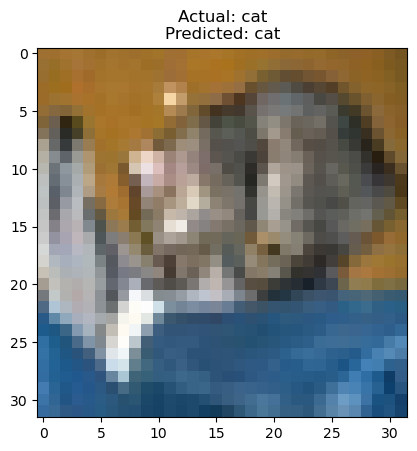

In [89]:
#Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Train the model
history=model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))
#Evalute the model
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print("Test Loss :",test_loss)
print("Test Accuracy: ",test_accuracy)
#make prediction
predictions=model.predict(x_test)
#Select first image
index=0
predicted_class=np.argmax(predictions[index])
actual_class=y_test[index][0]
print("Actual Class :",class_names[actual_class])
print("Predicted Class :",class_names[predicted_class])
#Display test image
plt.imshow(x_test[index])
plt.title("Actual: "+class_names[actual_class]+"\nPredicted: "+class_names[predicted_class])
plt.axis=('off')
plt.show()
#plot Accuracy